# 02 - Analise de pedidos 

Objetivo: Entender o ciclo de vida dos pedidas na plataforma Olist.

Perguntas que esse notebook responde: 
- Qual o volume de pedidos ao longo do tempo? Existe sazonalidade? 
- Qual o tempo médio de entrega por estado?
- Pedidos atrasados recebem avaliações piores? 
- Quais os métodos de pagamento mais usados?

Datasets utilizados: orders, order_item, payments e revies.

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

In [4]:
DATA_PATH = '../data/raw/' 

orders = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')

In [5]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

for col in date_cols: 
    orders[col] = pd.to_datetime(orders[col])

### 1. Volume de pedidos ao longo do tempo

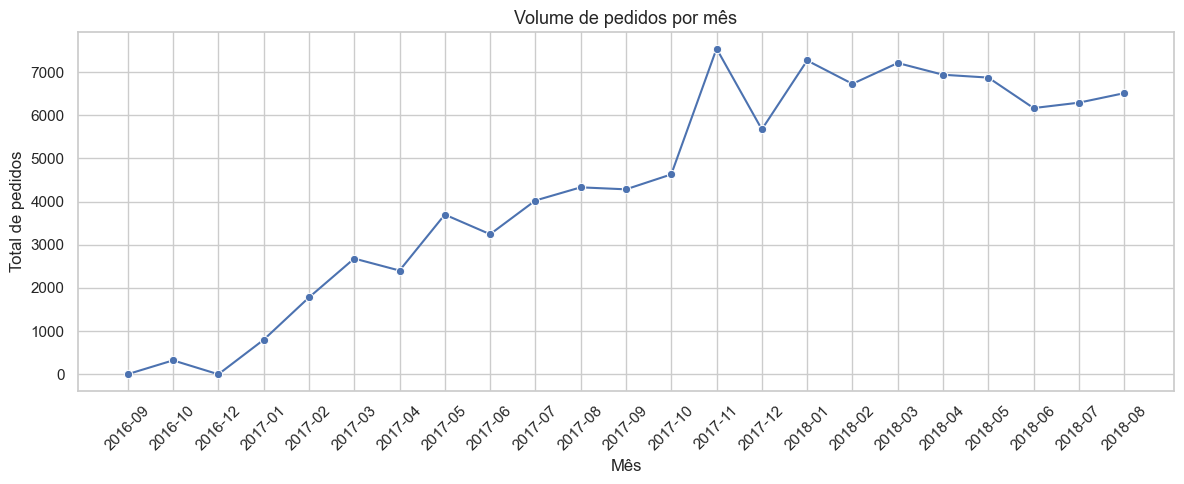

In [6]:
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_volume = (
    orders
    .groupby('year_month')
    .size()
    .reset_index(name='orders_total')
)

monthly_volume['year_month'] = monthly_volume['year_month'].astype(str)
monthly_volume = monthly_volume[monthly_volume['year_month'] < '2018-09']

fig, ax = plt.subplots()
sns.lineplot(data=monthly_volume, x='year_month', y='orders_total', ax=ax, marker='o')

ax.set_title('Volume de pedidos por mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Total de pedidos')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/02_montly_volume.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão

O volume de pedidos cresce consistentemente ao longo de 2017, com pico
expressivo em novembro de 2017 — coincidindo com a Black Friday —
seguido de queda em dezembro, possivelmente por antecipação das compras
no mês anterior.

Os dados de setembro de 2018 foram removidos da análise por estarem
incompletos — o dataset cobre apenas os primeiros dias do mês, o que
geraria uma queda artificial no gráfico.

## 2. Tempo médio de entrega por estado

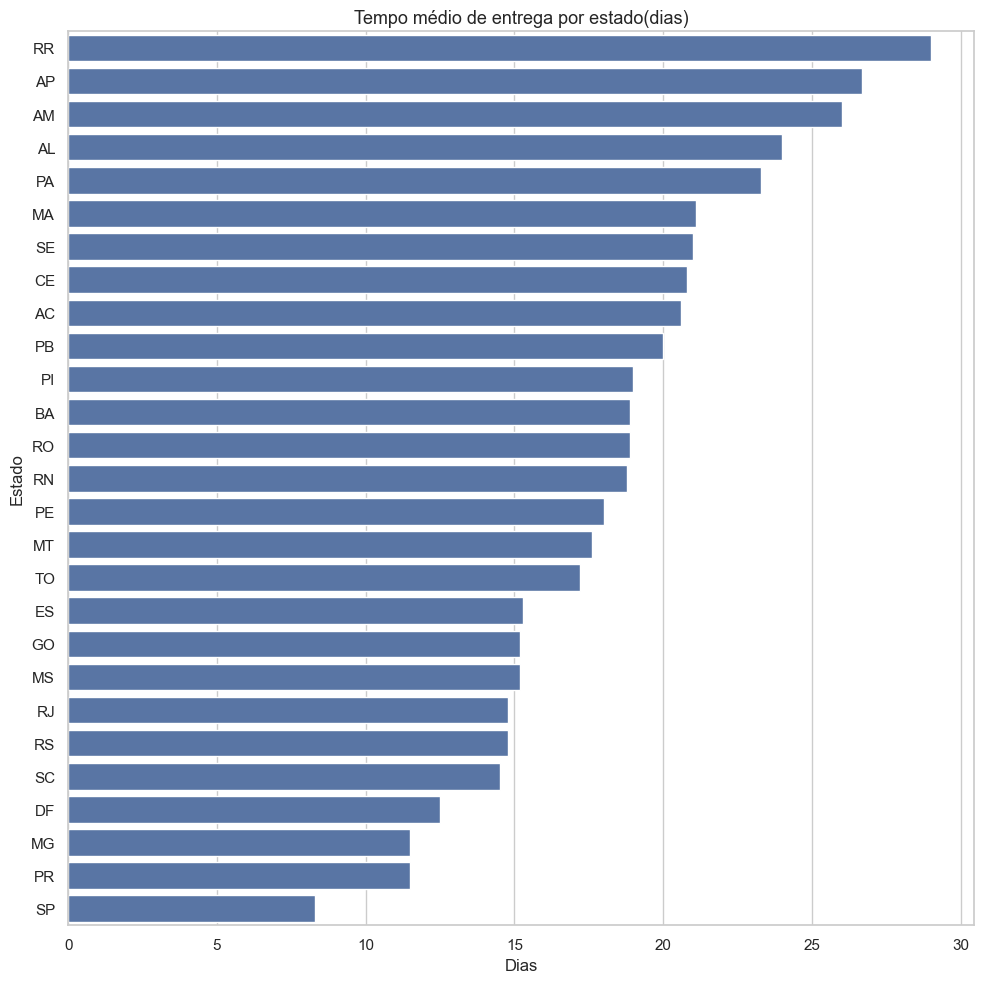

In [7]:
orders['tempo_entrega_dias'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days 

orders_delivered = orders[orders['order_delivered_customer_date'].notna()].copy()

customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

orders_with_state = pd.merge(
    orders_delivered, 
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

orders_by_state = (
    orders_with_state
    .groupby('customer_state')['tempo_entrega_dias']
    .mean()
    .round(1)
    .sort_values(ascending=False)
    .reset_index())

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=orders_by_state,
    x='tempo_entrega_dias',
    y='customer_state',
    ax=ax
)

ax.set_title('Tempo médio de entrega por estado(dias)')
ax.set_xlabel('Dias')
ax.set_ylabel('Estado')

plt.tight_layout()
plt.savefig('../reports/figures/02_entrega_por_estado.png', dpi=150, bbox_inches='tight')
plt.show()


### Conclusão

O tempo médio de entrega varia significativamente entre os estados.
Roraima (RR) apresenta o maior tempo médio — reflexo do isolamento
geográfico e da infraestrutura logística limitada da região Norte.
São Paulo (SP) é o estado com entrega mais rápida, o que faz sentido
dado que a maioria dos vendedores e centros de distribuição estão
concentrados no Sudeste.

Essa disparidade geográfica é um ponto de atenção para uma operação
real: clientes do Norte e Nordeste têm uma experiência de entrega
estruturalmente pior, o que pode impactar diretamente a satisfação
e a retenção nessas regiões.

## 3. Pedidos atrasados recebem avaliações piores?

In [13]:
orders_delivered['atrasados'] = (
    orders_delivered['order_delivered_customer_date'] >
    orders_delivered['order_estimated_delivery_date']
)

print(orders_delivered['atrasados'].value_counts())
print(f"\n% de atraso: {orders_delivered['atrasados'].mean() * 100:.1f}%")

atrasados
False    88649
True      7827
Name: count, dtype: int64

% de atraso: 8.1%


Criei uma coluna chamada "atrasados", que pode ser True(Verdadeiro) ou False(Falso). Nela, comparando o datetime tanto do envio do produto('order_delivered_customer_date') quanto da estimativa de recebimento do cliente('order_estimated_delivery_date'), identifiquei quantos produtos atrasaram e quantos chegaram dentro da estimativa correta.

Nessa analise, foi identificado 8,1% de atraso nas entregas, o que significa que, aproximadamente, 1 em cada 12 pedidos chegou depois do prazo estipulado. Em um e-commerce com 100 mil pedidos, são quase 8 mil clientes com experiência ruim.

In [12]:
orders_with_review = pd.merge(
    orders_delivered[['order_id', 'atrasados']],
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

print(orders_with_review.shape)

(96359, 3)


Criei uma nova tabela associando cada order_id (identificador único do pedido) ao status de atraso (verdadeiro para pedidos atrasados e falso para pedidos no prazo) e ao respectivo review.  

Os pedidos sem review foram descartados da análise, sem impacto significativo nos resultados, uma vez que representam menos de 1% do total de pedidos entregues.

A tabela resultante é composta por 96.359 linhas (pedidos entregues únicos) e 3 colunas: order_id (identificador único do pedido), atrasados (verdadeiro ou falso) e review.

In [14]:
general_avarage = orders_with_review['review_score'].mean()

avarage_by_group = (
    orders_with_review
    .groupby('atrasados')['review_score']
    .mean()
    .round(2)
)

print(f'Média geral: {general_avarage:.2f}')
print(f'Média no prazo: {avarage_by_group[False]:.2f}')
print(f'Média atrasados: {avarage_by_group[True]:.2f}')

Média geral: 4.16
Média no prazo: 4.29
Média atrasados: 2.57


A média geral das avaliações foi de 4,16.
Pedidos entregues no prazo apresentaram média de 4,29, enquanto pedidos atrasados obtiveram média de 2,57.

Observa-se uma diferença de 1,72 pontos entre os grupos, indicando uma associação relevante entre atraso na entrega e avaliações mais baixas.

Considerando uma escala de 1 a 5, essa diferença representa uma variação significativa na percepção dos clientes. Enquanto pedidos no prazo apresentam avaliações acima da média geral, pedidos atrasados concentram avaliações substancialmente inferiores.

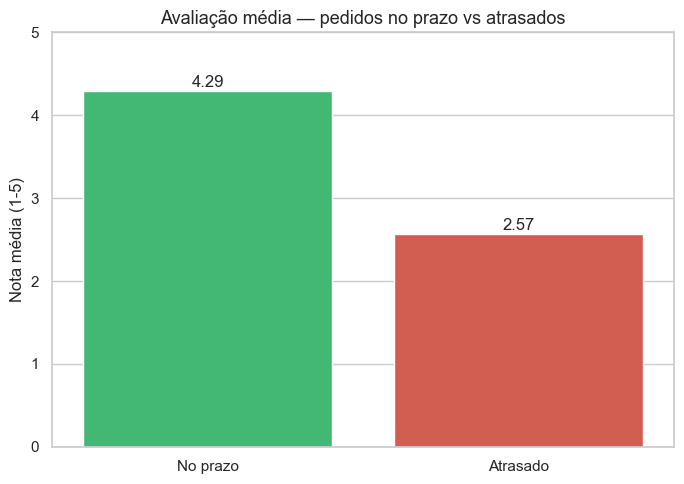

In [15]:
medias = pd.DataFrame({
    'grupo': ['No prazo', 'Atrasado'],
    'media': [avarage_by_group[False], avarage_by_group[True]]
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=medias, x='grupo', y='media', ax=ax, palette=['#2ecc71', '#e74c3c'])

ax.set_title('Avaliação média — pedidos no prazo vs atrasados')
ax.set_xlabel('')
ax.set_ylabel('Nota média (1-5)')
ax.set_ylim(0, 5)

for bar, valor in zip(ax.patches, medias['media']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{valor:.2f}',
        ha='center', fontsize=12
    )

plt.tight_layout()
plt.savefig('../reports/figures/02_atraso_vs_avaliacao.png', dpi=150, bbox_inches='tight')
plt.show()

Plotei um gráfico para representar visualmente os dados da análise.

legenda: 
> **Verde** — pedidos entregues dentro do prazo estimado  
> **Vermelho** — pedidos entregues após o prazo estimado  
> Escala de avaliação: 1 (péssimo) a 5 (ótimo)

### Conclusão

Pedidos atrasados recebem nota média de 2.57 — contra 4.29 dos pedidos
entregues no prazo. Uma queda de 1.72 pontos numa escala de 1 a 5.

Com 8.1% dos pedidos atrasando, isso representa ~8.000 clientes por
ano com experiência significativamente pior. Em um cenário real, reduzir
o índice de atraso pela metade teria impacto direto e mensurável no NPS
da plataforma.